# Robustness and explainability Notebook

**Purpose.** The fifth objective of the report:
1. **Robustness to the choice of learning algorithm.** Two further model families, XGBoost and support vector regression (SVR), each tuned by nested cross-validation inside every training fold, are fitted to the same four arms on the same 100 splits as the primary analyses. A sensitivity analysis refits both with their libraries' default settings, to show whether tuning changes the findings.
2. **Grouped permutation importance.** For Arms A and C, each group of related features (and ichorCNA) is shuffled on the held-out test folds, and the resulting increase in error measures how much each model relies on that group.

**Inputs:** `results/features_wgs.csv` (notebook 01) and `results/ablation.pkl` (notebook 02).

In [2]:
# ---- Setup: imports, run mode and folders --------------------------------------------
import os, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.exceptions import ConvergenceWarning

import common, engine
from common import load, feature_matrix, sha256, logit, expit, LENGTHS, EXPECTED_SHA256
from engine import splits, fit_predict, pooled_metrics, nb_corrected_t
import collections
import robustness as rob

# Elastic-net fits at the weakest penalties on the path can stop before full convergence;
# this is expected and does not affect the selected model, so these warnings are hidden.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
# openpyxl warns about an Excel extension it cannot read; it does not affect the data.
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

# Output folders: tables and cached results in results/, figures in figures/
RES = Path("results")
FIG = Path("figures")
RES.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
DATA = Path("data/elife-71569-supp1-v2.xlsx")

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
print("Repeats:", engine.N_REPEATS, "| random-forest trees:", engine.RF_TREES)

Repeats: 20 | random-forest trees: 500


In [3]:
F = pd.read_csv(RES / "features_wgs.csv")
F = F[F.vaf_ctdna.notna()].reset_index(drop=True)
y = F.vaf_ctdna.to_numpy()
frag_cols = [col for col in F.columns if col not in ("ichorCNA", "vaf_ctdna")]
XA = F[frag_cols].to_numpy(); XB = logit(F[["ichorCNA"]].to_numpy()); XC = np.column_stack([XA, XB])
arms = {"A1_shortlong": F[["short_long_ratio"]].to_numpy(), "A_frag14": XA, "B_ichor": XB, "C_combined": XC}
# feature groups for importance (the four aspects of the distribution, plus ichorCNA in Arm C)
gA = {g: [frag_cols.index(f) for f in fs] for g, fs in rob.GROUPS.items()}
groups = {"A_frag14": gA, "C_combined": {**gA, "ichorCNA": [XC.shape[1] - 1]}}
S = splits(len(y)); n_tr, n_te = len(y) * 4 / 5, len(y) / 5
primary = pickle.load(open(RES / "ablation.pkl", "rb"))       # elastic net, random forest and null model from notebook 02
print("Tuning grids:\n  XGBoost:", rob.XGB_GRID, "\n  SVR:", rob.SVR_GRID)

Tuning grids:
  XGBoost: {'max_depth': [1, 2, 3], 'learning_rate': [0.03, 0.1], 'n_estimators': [100, 300]} 
  SVR: {'svr__C': [0.1, 1, 10, 100], 'svr__gamma': ['scale', 0.01, 0.1], 'svr__epsilon': [0.05, 0.2]}


## 1. Fit XGBoost and SVR (and importance for all four model families)

Each XGBoost and SVR fit is a grid search with an inner five-fold split of the training fold, so tuning never sees the test fold. The elastic net and random forest are refitted only for Arms A and C, to compute their importance; with the same seeds, their predictions are identical to notebook 02.

In [4]:
R = {}
jobs = [(k, a) for k in ("SVR", "XGB", "SVR_default", "XGB_default") for a in arms] + [(k, a) for k in ("EN", "RF") for a in ("A_frag14", "C_combined")]
for kind, arm in jobs:
    cache = RES / f"robustness_{kind}_{arm}.pkl"
    if cache.exists():
        R[(kind, arm)] = pickle.load(open(cache, "rb"))
    else:
        t0 = time.time()
        R[(kind, arm)] = rob.run(kind, arm, arms[arm], y, S, None if kind.endswith("_default") else groups.get(arm))
        pickle.dump(R[(kind, arm)], open(cache, "wb"))
        print(f"{kind} {arm}: done ({time.time() - t0:.0f} s)")
for arm in arms:                                               # primary results, for comparison
    for kind in ("EN", "RF"):
        R.setdefault((kind, arm), primary[(arm, kind)])
R[("Null", "-")] = primary[("Null", "-")]
print(len(R), "model-arm results available")

SVR A1_shortlong: done (36 s)
SVR A_frag14: done (47 s)
SVR B_ichor: done (43 s)
SVR C_combined: done (48 s)
XGB A1_shortlong: done (4158 s)
XGB A_frag14: done (3252 s)
XGB B_ichor: done (1485 s)
XGB C_combined: done (1769 s)
SVR_default A1_shortlong: done (0 s)
SVR_default A_frag14: done (0 s)
SVR_default B_ichor: done (0 s)
SVR_default C_combined: done (0 s)
XGB_default A1_shortlong: done (25 s)
XGB_default A_frag14: done (22 s)
XGB_default B_ichor: done (21 s)
XGB_default C_combined: done (20 s)
EN A_frag14: done (35 s)
EN C_combined: done (29 s)
RF A_frag14: done (500 s)
RF C_combined: done (954 s)
25 model-arm results available


## 2. Performance of all four model families

Metrics are pooled over the 86 out-of-fold predictions in each repeat and summarised by their median (with 2.5th–97.5th percentiles for RMSE). The corrected test is the same as in the primary analysis. The C − B tests for XGBoost and SVR are Holm-adjusted.

In [5]:
LAB = {"A1_shortlong": "A1", "A_frag14": "A", "B_ichor": "B", "C_combined": "C"}
rows = []
for kind in ("EN", "RF", "XGB", "SVR"):
    for arm in arms:
        ms = pd.DataFrame([pooled_metrics(y, R[(kind, arm)]["raw"][r]) for r in range(engine.N_REPEATS)])
        rows.append(dict(model=kind, arm=LAB[arm], rmse=ms.rmse.median(), rmse_p2_5=ms.rmse.quantile(.025), rmse_p97_5=ms.rmse.quantile(.975),
                         mae=ms.mae.median(), r2=ms.r2.median(), spearman=ms.spearman.median(), cal_slope=ms.cal_slope.median(), citl=ms.citl.median()))
perf = pd.DataFrame(rows); perf.to_csv(RES / "table_4_7_performance.csv", index=False)
display(perf.round(3))

,model,arm,rmse,rmse_p2_5,rmse_p97_5,mae,r2,spearman,cal_slope,citl
0,EN,A1,0.204,0.200,0.209,0.148,0.399,0.614,0.923,0.045
1,EN,A,0.172,0.164,0.188,0.118,0.571,0.731,0.928,0.029
2,EN,B,0.163,0.160,0.168,0.114,0.617,0.823,0.947,0.017
3,EN,C,0.157,0.150,0.174,0.107,0.641,0.823,0.966,0.025
4,RF,A1,0.211,0.203,0.228,0.160,0.354,0.573,0.762,0.025
5,RF,A,0.178,0.168,0.193,0.121,0.541,0.749,1.035,0.037
6,RF,B,0.175,0.163,0.185,0.122,0.558,0.777,0.877,0.008
7,RF,C,0.158,0.149,0.175,0.105,0.639,0.820,1.055,0.027
8,XGB,A1,0.203,0.196,0.215,0.150,0.402,0.582,0.874,0.035
9,XGB,A,0.183,0.167,0.201,0.129,0.514,0.740,0.896,0.026


In [7]:
rows = []
for kind in ("EN", "RF", "XGB", "SVR"):
    for a, b in [("C_combined", "B_ichor"), ("A_frag14", "B_ichor"), ("C_combined", "A_frag14"), ("A_frag14", "A1_shortlong"), ("B_ichor", "Null")]:
        kb = ("Null", "-") if b == "Null" else (kind, b)
        r = nb_corrected_t(R[(kind, a)]["fold_rmse"] - R[kb]["fold_rmse"], n_tr, n_te)
        rows.append(dict(model=kind, contrast=f"{LAB.get(a, a)} - {LAB.get(b, b)}", **r))
contrasts = pd.DataFrame(rows)
sel = (contrasts.contrast == "C - B") & contrasts.model.isin(["XGB", "SVR"])
contrasts.loc[sel, "p_holm"] = rob.holm(contrasts.loc[sel, "p"].to_numpy())
contrasts.to_csv(RES / "table_4_7_contrasts.csv", index=False)
display(contrasts.round(4))

rows = []                                                      # each family against the elastic net, within each arm
for kind in ("RF", "XGB", "SVR"):
    for arm in arms:
        r = nb_corrected_t(R[(kind, arm)]["fold_rmse"] - R[("EN", arm)]["fold_rmse"], n_tr, n_te)
        rows.append(dict(comparison=f"{kind} - EN", arm=LAB[arm], **r))
family = pd.DataFrame(rows); family.to_csv(RES / "table_4_7_family.csv", index=False)
display(family.round(4))

rows = []                                                      # which tuning settings were chosen most often
for kind in ("XGB", "SVR"):
    for arm in arms:
        counts = collections.Counter(tuple(sorted(p.items())) for p in R[(kind, arm)]["params"])
        best, n = counts.most_common(1)[0]
        rows.append(dict(model=kind, arm=LAB[arm], most_frequent_setting=dict(best), share_of_splits=n / len(S)))
tuning = pd.DataFrame(rows); tuning.to_csv(RES / "table_4_7_tuning_choices.csv", index=False)
display(tuning)

,model,contrast,mean,lo,hi,t,p,p_holm
0,EN,C - B,-0.0059,-0.0251,0.0133,-0.6086,0.5442,NaN
1,EN,A - B,0.0089,-0.0193,0.0371,0.6268,0.5323,NaN
2,EN,C - A,-0.0148,-0.0345,0.0049,-1.4932,0.1386,NaN
3,EN,A - A1,-0.0300,-0.0640,0.0041,-1.7478,0.0836,NaN
4,EN,B - Null,-0.1111,-0.1538,-0.0685,-5.1759,0.0000,NaN
5,RF,C - B,-0.0162,-0.0471,0.0147,-1.0386,0.3015,NaN
6,RF,A - B,0.0049,-0.0286,0.0383,0.2876,0.7742,NaN
7,RF,C - A,-0.0210,-0.0345,-0.0076,-3.1146,0.0024,NaN
8,RF,A - A1,-0.0343,-0.0726,0.0040,-1.7772,0.0786,NaN
9,RF,B - Null,-0.1006,-0.1470,-0.0542,-4.3004,0.0000,NaN


,comparison,arm,mean,lo,hi,t,p
0,RF - EN,A1,0.0108,-0.0159,0.0376,0.8055,0.4225
1,RF - EN,A,0.0065,-0.0197,0.0327,0.4925,0.6234
2,RF - EN,B,0.0106,-0.0073,0.0284,1.1756,0.2426
3,RF - EN,C,0.0003,-0.0249,0.0254,0.0202,0.9839
4,XGB - EN,A1,0.0007,-0.0225,0.0239,0.0586,0.9534
5,XGB - EN,A,0.0111,-0.0158,0.0380,0.8193,0.4146
6,XGB - EN,B,0.0054,-0.0110,0.0219,0.6557,0.5135
7,XGB - EN,C,0.0035,-0.0237,0.0307,0.2552,0.7991
8,SVR - EN,A1,-0.0004,-0.0188,0.0179,-0.0448,0.9643
9,SVR - EN,A,-0.0074,-0.0257,0.0109,-0.8053,0.4226


,model,arm,most_frequent_setting,share_of_splits
0,XGB,A1,"{'learning_rate': 0.03, 'max_depth': 1, 'n_est...",0.75
1,XGB,A,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est...",0.19
2,XGB,B,"{'learning_rate': 0.03, 'max_depth': 1, 'n_est...",0.67
3,XGB,C,"{'learning_rate': 0.03, 'max_depth': 1, 'n_est...",0.30
4,SVR,A1,"{'svr__C': 1, 'svr__epsilon': 0.2, 'svr__gamma...",0.29
5,SVR,A,"{'svr__C': 100, 'svr__epsilon': 0.05, 'svr__ga...",0.29
6,SVR,B,"{'svr__C': 10, 'svr__epsilon': 0.2, 'svr__gamm...",0.34
7,SVR,C,"{'svr__C': 10, 'svr__epsilon': 0.2, 'svr__gamm...",0.64


## 2b. Effect of tuning (Table 4.7, Panel C)

Each of XGBoost and SVR is compared with its library defaults (XGBoost: depth 6, learning rate 0.3, 100 rounds; SVR: C = 1, gamma = scale, epsilon = 0.1). Positive default-minus-tuned differences mean that tuning reduced the error.

In [8]:
rows = []
for base in ("XGB", "SVR"):
    for version, kind in (("tuned", base), ("default", base + "_default")):
        row = dict(model=base, version=version)
        for arm in arms:
            row[f"rmse_{LAB[arm]}"] = np.median([pooled_metrics(y, R[(kind, arm)]["raw"][r])["rmse"] for r in range(engine.N_REPEATS)])
        cb = nb_corrected_t(R[(kind, "C_combined")]["fold_rmse"] - R[(kind, "B_ichor")]["fold_rmse"], n_tr, n_te)
        row.update(C_minus_B=cb["mean"], lo=cb["lo"], hi=cb["hi"], p=cb["p"],
                   slope_C=np.median([pooled_metrics(y, R[(kind, "C_combined")]["raw"][r])["cal_slope"] for r in range(engine.N_REPEATS)]))
        rows.append(row)
tuning_effect = pd.DataFrame(rows); tuning_effect.to_csv(RES / "table_4_7_tuning_effect.csv", index=False)
display(tuning_effect.round(3))

rows = []
for base in ("XGB", "SVR"):
    for arm in arms:
        r = nb_corrected_t(R[(base + "_default", arm)]["fold_rmse"] - R[(base, arm)]["fold_rmse"], n_tr, n_te)
        rows.append(dict(model=base, arm=LAB[arm], default_minus_tuned=r["mean"], lo=r["lo"], hi=r["hi"], p=r["p"]))
default_vs_tuned = pd.DataFrame(rows); default_vs_tuned.to_csv(RES / "table_4_7_default_vs_tuned.csv", index=False)
display(default_vs_tuned.round(4))

,model,version,rmse_A1,rmse_A,rmse_B,rmse_C,C_minus_B,lo,hi,p,slope_C
0,XGB,tuned,0.203,0.183,0.166,0.160,-0.008,-0.040,0.024,0.629,0.960
1,XGB,default,0.278,0.194,0.206,0.179,-0.025,-0.091,0.041,0.458,0.814
2,SVR,tuned,0.203,0.162,0.161,0.144,-0.017,-0.045,0.011,0.236,0.933
3,SVR,default,0.198,0.163,0.162,0.149,-0.012,-0.041,0.017,0.411,1.106


,model,arm,default_minus_tuned,lo,hi,p
0,XGB,A1,0.0757,0.0260,0.1253,0.0032
1,XGB,A,0.0107,-0.0154,0.0367,0.4187
2,XGB,B,0.0349,-0.0151,0.0849,0.1691
3,XGB,C,0.0179,-0.0070,0.0428,0.1574
4,SVR,A1,-0.0052,-0.0168,0.0065,0.3795
5,SVR,A,-0.0003,-0.0169,0.0162,0.9668
6,SVR,B,0.0004,-0.0124,0.0131,0.9561
7,SVR,C,0.0050,-0.0170,0.0270,0.6519


## 3. Grouped permutation importance

Importance is the increase in test-fold RMSE when a group of features is shuffled, averaged over five permutations per split and summarised across the 100 splits. It describes what each fitted model relies on; it does not, on its own, show that a group adds predictive value (that question is answered by the ablation).

In [9]:
rows = []
for kind in ("EN", "RF", "XGB", "SVR"):
    for arm in ("A_frag14", "C_combined"):
        imp = pd.DataFrame(R[(kind, arm)]["importance"])
        for g in imp.columns:
            rows.append(dict(model=kind, arm=LAB[arm], group=g, mean_increase_rmse=imp[g].mean(),
                             p2_5=imp[g].quantile(.025), p97_5=imp[g].quantile(.975)))
importance = pd.DataFrame(rows); importance.to_csv(RES / "table_4_8_importance.csv", index=False)
display(importance.pivot_table(index="group", columns=["arm", "model"], values="mean_increase_rmse").round(4))

# elastic-net selection frequency: share of splits in which each predictor kept a non-zero coefficient
sel_rows = []
for arm, names in (("A_frag14", frag_cols), ("C_combined", frag_cols + ["ichorCNA"])):
    C = np.array(R[("EN", arm)]["coefs"])
    for j, name in enumerate(names):
        sel_rows.append(dict(arm=LAB[arm], feature=name, selected_share=(np.abs(C[:, j]) > 1e-10).mean(), mean_coefficient=C[:, j].mean()))
selection = pd.DataFrame(sel_rows); selection.to_csv(RES / "table_4_8_en_selection.csv", index=False)
display(selection[selection.arm == "C"].sort_values("selected_share", ascending=False).round(3))

arm                              A                               C          \
model                           EN      RF     SVR     XGB      EN      RF   
group                                                                        
Dinucleosomal content       0.0477  0.0077  0.0318  0.0167  0.0039  0.0034   
Mononucleosomal peak shape  0.0118  0.0027  0.0083  0.0017  0.0002  0.0010   
Overall distribution shape  0.0335  0.0370  0.0464  0.0237  0.0055  0.0153   
Short-fragment enrichment   0.1341  0.0490  0.1048  0.0699  0.0343  0.0308   
ichorCNA                       NaN     NaN     NaN     NaN  0.0905  0.0641   

arm                                         
model                          SVR     XGB  
group                                       
Dinucleosomal content       0.0050  0.0021  
Mononucleosomal peak shape  0.0039  0.0007  
Overall distribution shape  0.0230  0.0093  
Short-fragment enrichment   0.0383  0.0326  
ichorCNA                    0.0695  0.0928

,arm,feature,selected_share,mean_coefficient
14,C,short_long_ratio,1.00,0.311
28,C,ichorCNA,1.00,0.736
19,C,di_mono_ratio,0.83,0.127
27,C,iqr_length,0.70,0.059
16,C,mono_peak_pos,0.63,-0.049
20,C,periodicity_10bp,0.56,-0.063
25,C,kurtosis,0.48,-0.063
15,C,sub_nucleosomal_frac,0.43,0.076
21,C,entropy,0.31,0.013
23,C,sd_length,0.31,0.024


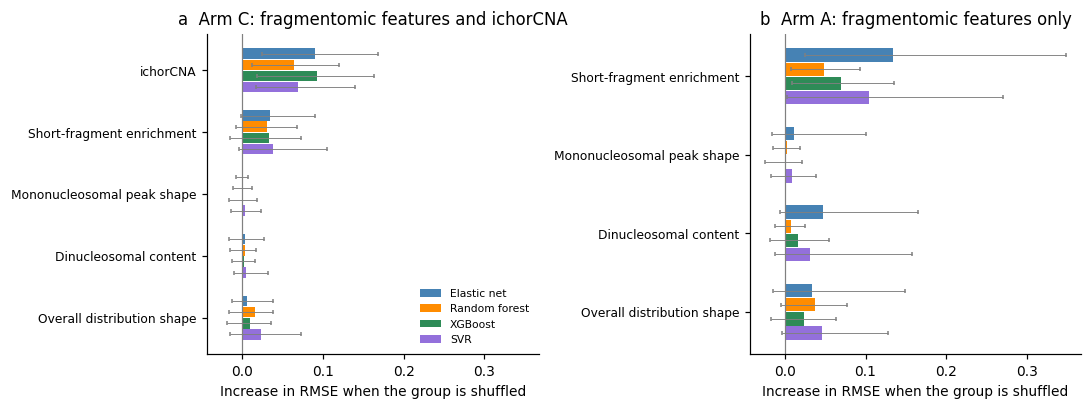

In [10]:
# Figure: grouped importance in Arm C (left) and Arm A (right), by model family
colours = {"EN": "steelblue", "RF": "darkorange", "XGB": "seagreen", "SVR": "mediumpurple"}
names = {"EN": "Elastic net", "RF": "Random forest", "XGB": "XGBoost", "SVR": "SVR"}
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for a_, arm, title in ((ax[0], "C", "a  Arm C: fragmentomic features and ichorCNA"), (ax[1], "A", "b  Arm A: fragmentomic features only")):
    sub = importance[importance.arm == arm]
    order = ["ichorCNA"] + list(rob.GROUPS) if arm == "C" else list(rob.GROUPS)
    for j, kind in enumerate(("EN", "RF", "XGB", "SVR")):
        s_ = sub[sub.model == kind].set_index("group").loc[order]
        ypos = np.arange(len(order)) + (j - 1.5) * 0.18
        a_.barh(ypos, s_.mean_increase_rmse, height=0.17, color=colours[kind], label=names[kind])
        a_.errorbar(s_.mean_increase_rmse, ypos, xerr=[s_.mean_increase_rmse - s_.p2_5, s_.p97_5 - s_.mean_increase_rmse],
                    fmt="none", ecolor="grey", elinewidth=0.6, capsize=1.5)
    a_.set_yticks(np.arange(len(order))); a_.set_yticklabels(order, fontsize=8); a_.invert_yaxis()
    a_.axvline(0, color="grey", linewidth=0.8)
    a_.set(title=title, xlabel="Increase in RMSE when the group is shuffled")
ax[0].legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout(); fig.savefig(FIG / "fig4_7_importance.png", dpi=150); plt.show()

In [11]:
import pickle, numpy as np
for arm in ("B_ichor", "C_combined"):
    ps = pickle.load(open(RES / f"robustness_XGB_{arm}.pkl", "rb"))["params"]
    print(arm, "depth-1 share:", round(np.mean([p["max_depth"] == 1 for p in ps]), 2))
b = R[("XGB_default", "B_ichor")]["raw"]; c = R[("XGB_default", "C_combined")]["raw"]
print("default XGBoost, C better in", sum(pooled_metrics(y, c[r])["rmse"] < pooled_metrics(y, b[r])["rmse"] for r in range(20)), "of 20 repeats")


B_ichor depth-1 share: 0.92
C_combined depth-1 share: 0.52
default XGBoost, C better in 19 of 20 repeats
